Copyright 2025 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Fine-tune FunctionGemma 270M for Mobile Actions with LoRA

This notebook fine-tunes FunctionGemma for the task of mapping user requests to mobile actions using the Hugging Face Transformer Reinforcement Learning ([TRL](https://huggingface.co/docs/trl/en/index)) library.

Originally, training [FunctionGemma 270M](https://huggingface.co/google/functiongemma-270m-it) on the Mobile Actions dataset followed a full fine-tuning recipe that required a Google Colab **A100 GPU**, taking roughly **60 minutes end to end**.

This notebook now uses **LoRA (Low-Rank Adaptation)** for fine-tuning, with an optional **QLoRA** setup. Thanks to this approach, training can be performed on a **single NVIDIA T4 GPU**, which is available on **free Google Colab**. Despite taking slightly longer (about 4 hours end-to-end), it is free and achieves very similar performance to the original full fine-tuning setup.

Run each code snippet to:

1. Set up the Colab environment  
2. Prepare a dataset for fine-tuning  
3. Load and test the base FunctionGemma 270M model  
4. Fine-tune the model using LoRA (or QLoRA)  
5. Test, evaluate, and save the model for further use  
6. Convert the checkpoint to `.litertlm` for deployment  

## Prerequisites

This notebook **no longer requires an A100 GPU**.

- Recommended: **NVIDIA T4 GPU** (available on free Google Colab)
- Optional: A100 GPU will speed up the process but cost you money!

## Set up development environment

The first step is to install the necessary libraries using the `pip` package installer.


In [ ]:
%pip install torch
%pip install -U transformers==4.57.1 trl==0.25.1 datasets==4.4.1
%pip install -U bitsandbytes

**You may have to restart your session (runtime) to use newly installed libraries.**

##Enable Hugging Face permissions

To use Gemma models, you'll need to accept the model usage license and create an Access Token:

1. **Accept license** on the [model page](http://huggingface.co/google/functiongemma-270m-it).

2. **Get a valid [Access Token](https://huggingface.co/settings/tokens) with 'Write' access (very important!)**

3. **Create a new Colab secret** in the left toolbar. Specify `HF_TOKEN` as the 'Name', add your unique token as the 'Value', and toggle 'Notebook access' on.

In [ ]:
from google.colab import userdata
from huggingface_hub import login

# Login into Hugging Face Hub
hf_token = userdata.get('HF_TOKEN')
login(hf_token)
print(..)

..


### If you are using Kaggle uncomment the cell below to ensure we are using only one of the T4 GPUs
(or the training will fail because the code is not prepared for a multi-GPU setup)

In [ ]:
# import os

# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# import torch
# print("CUDA devices visible:", torch.cuda.device_count())
# print("Current device:", torch.cuda.current_device())
# print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

CUDA devices visible: 1
Current device: 0
Device name: Tesla T4


## Load the model

You can access [FunctionGemma 270M](https://huggingface.co/google/functiongemma-270m-it) from Hugging Face Hub by accepting the license terms. The instruction-tuned version of the model has already been trained on how to follow directions and with fine-tuning, you'll now adapt it to a new task.

In [ ]:
from transformers import BitsAndBytesConfig
import torch

# Add quantization to the model (QLoRA instead of simple LoRA)
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

gemma_model = "google/functiongemma-270m-it"
base_model = AutoModelForCausalLM.from_pretrained(
    gemma_model,
    quantization_config=quantization_config, # Remove this line if you want to use simple LoRA instead of QLoRA (slightly faster but uses more memory)
    device_map="auto",
    attn_implementation="eager",
    dtype="auto")

tokenizer = AutoTokenizer.from_pretrained(gemma_model)

print(f"Device: {base_model.device}")
print(f"DType:  {base_model.dtype}")

config.json:   0%|          | 0.00/1.32k [00:00<?, ?B/s]

2025-12-27 12:49:30.940860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766839771.124990     120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766839771.180313     120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766839771.633291     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766839771.633325     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766839771.633329     120 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/63.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/13.8k [00:00<?, ?B/s]

Device: cuda:0
DType:  torch.bfloat16


Device should print as `cuda` if you're using a GPU runtime.

## Load the dataset

To fine-tune FunctionGemma, we utilize the [Mobile Actions
dataset](https://huggingface.co/datasets/google/mobile-actions), which is
publicly available on Hugging Face. Each entry in this dataset provides:

*   The set of tools (functions) the model can use:
    1. Turn the flashlight on
    2. Turn the flashlight off
    3. Create a contact in the phone's contact list
    4. Send an email
    5. Show a location on the map
    6. Open the WiFi settings
    7. Create a new calendar event
*   The system prompt providing the context like current date and time
*   The user prompt, like `turn on the flashlight`.
*   The expected model response, including the appropriate function calls.

In [ ]:
import json
from random import randint
from datasets import load_dataset
from transformers import AutoTokenizer
from huggingface_hub import hf_hub_download

data_file = hf_hub_download(repo_id="google/mobile-actions", filename="dataset.jsonl", repo_type="dataset")
dataset = load_dataset("text", data_files=data_file, encoding="utf-8")["train"].shuffle()

print(f"\n\033[1mHere's an example from your dataset:\033[0m \n{json.dumps(json.loads(dataset[randint(0, len(dataset) - 1)]['text']), indent=2)}")

dataset.jsonl:   0%|          | 0.00/25.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]


Here's an example from your dataset: 
{
  "metadata": "train",
  "tools": [
    {
      "function": {
        "name": "send_email",
        "description": "Sends an email.",
        "parameters": {
          "type": "OBJECT",
          "properties": {
            "to": {
              "type": "STRING",
              "description": "The email address of the recipient."
            },
            "body": {
              "type": "STRING",
              "description": "The body of the email."
            },
            "subject": {
              "type": "STRING",
              "description": "The subject of the email."
            }
          },
          "required": [
            "to",
            "subject"
          ]
        }
      }
    },
    {
      "function": {
        "name": "turn_on_flashlight",
        "description": "Turns the flashlight on.",
        "parameters": {
          "type": "OBJECT",
          "properties": {}
        }
      }
    },
    {
      "function": {
   

## Process the dataset for training and evaluation

Now that you've loaded your data, format the training dataset into [Prompt-completion](https://huggingface.co/docs/trl/main/en/dataset_formats#prompt-completion) format for more efficient training later (`completion_only_loss=True`). This means the model will only learn from the `completion` instead of the `prompt`.

- `prompt` for the non-trainable parts
- `completion` for the trainable parts

In [ ]:
import json

def apply_format(sample):
  template_iputs = json.loads(sample['text'])

  prompt_and_completion = tokenizer.apply_chat_template(
    template_iputs['messages'],
    tools=template_iputs['tools'],
    tokenize=False,
    # add_generation_prompt is False since we don't need model output after all
    # messages.
    add_generation_prompt=False)

  prompt = tokenizer.apply_chat_template(
    template_iputs['messages'][:-1],
    tools=template_iputs['tools'],
    tokenize=False,
    # add_generation_prompt is True since we would like to include
    # "<start_of_turn>model" in the prompt, if needed.
    add_generation_prompt=True)

  completion = prompt_and_completion[len(prompt):]

  return {
     "prompt": prompt,
     "completion": completion,
     "split": template_iputs["metadata"],
  }

processed_dataset = dataset.map(apply_format)

Map:   0%|          | 0/9654 [00:00<?, ? examples/s]

In [ ]:
#@title Review the processed dataset

print("\033[1mHere's an example from the formatted dataset:\033[0m")
print(json.dumps(processed_dataset[randint(0, len(processed_dataset) - 1)], indent=2))

longest_example = max(processed_dataset, key=lambda example: len(example['prompt'] + example['completion']))
longest_example_token_count = len(tokenizer.tokenize(longest_example['prompt'] + longest_example['completion']))

print(f"\n\033[1mThe longest example length is {len(longest_example['prompt'] + longest_example['completion'])} with {longest_example_token_count} tokens. We need to set the max_length larger than the token count in SFTConfig below.\033[0m")
print(json.dumps(longest_example, indent=2))

max_token_count = longest_example_token_count + 100
print(f"\n\033[1mUsing max_token_count of {max_token_count} (= {longest_example_token_count} + 100) for training below.\033[0m")

Here's an example from the formatted dataset:
{
  "text": "{\"metadata\": \"train\", \"tools\": [{\"function\": {\"name\": \"create_contact\", \"description\": \"Creates a contact in the phone's contact list.\", \"parameters\": {\"type\": \"OBJECT\", \"properties\": {\"last_name\": {\"type\": \"STRING\", \"description\": \"The last name of the contact.\"}, \"first_name\": {\"type\": \"STRING\", \"description\": \"The first name of the contact.\"}, \"phone_number\": {\"type\": \"STRING\", \"description\": \"The phone number of the contact.\"}, \"email\": {\"type\": \"STRING\", \"description\": \"The email address of the contact.\"}}, \"required\": [\"first_name\", \"last_name\"]}}}, {\"function\": {\"name\": \"open_wifi_settings\", \"description\": \"Opens the Wi-Fi settings.\", \"parameters\": {\"type\": \"OBJECT\", \"properties\": {}}}}, {\"function\": {\"name\": \"turn_off_flashlight\", \"description\": \"Turns the flashlight off.\", \"parameters\": {\"type\": \"OBJECT\", \"propertie

In [ ]:
#@title Prepare train and eval dataset.

train_dataset = processed_dataset.filter(lambda example: example['split'] == 'train')
eval_dataset = processed_dataset.filter(lambda example: example['split'] == 'eval')

print(len(train_dataset))
print(len(eval_dataset))

Filter:   0%|          | 0/9654 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9654 [00:00<?, ? examples/s]

8693
961


## Recommended: Test the base model

Now, we have loaded both the base model and the dataset. Let's first check how the base model's ability to respond to  
a random sample.

Try testing it a few times.

In [ ]:
#@title Test with a prompt

from transformers import pipeline
from random import randint
import re

# Create a transformers inference pipeline
pipe = pipeline("text-generation", model=gemma_model, tokenizer=tokenizer)

user_prompt = "Schedule a \"team meeting\" tomorrow at 4pm."  #@param {type:"string"}
messages = [
    {"role": "developer", "content": "Current date and time given in YYYY-MM-DDTHH:MM:SS format: 2024-11-15T05:59:00. You are a model that can do function calling with the following functions"},
    {"role": "user", "content": user_prompt}
]

# Reuse the tools from the sample
tools = json.loads(dataset[0]['text'])['tools']

prompt = tokenizer.apply_chat_template(
    messages,
    tools=tools,
    tokenize=False,
    add_generation_prompt=True)

print(f"\n\033[1mPrompt:\033[0m {user_prompt}")
output = pipe(prompt, max_new_tokens=max_token_count)
model_output = output[0]['generated_text'][len(prompt):].strip()

print(f"\n\033[1mBase model output:\033[0m {model_output}")

Note that how the base model is unable to successfully call the `create_calendar_event` function for this prompt.

Now, we will pick a sample from the training dataset and see how it performs.

## Test with training dataset


In [ ]:
from transformers import pipeline
from random import randint
import re

# Create a transformers inference pipeline
pipe = pipeline("text-generation", model=gemma_model, tokenizer=tokenizer)

# Select a random sample from the test dataset
rand_idx = randint(0, len(train_dataset) - 1)
test_sample = train_dataset[rand_idx]

input_prompt = test_sample['prompt']
expected_output = test_sample['completion']

# Generate the output
output = pipe(input_prompt, max_new_tokens=max_token_count, skip_special_tokens=False)
actual_output = output[0]['generated_text'][len(input_prompt):].strip()

print(f"\n\033[1mInput prompt\033[0m   : {input_prompt}")
print(f"\n\033[1mExpected output\033[0m: {expected_output}")
print(f"\n\033[1mActual output\033[0m  : {actual_output}")

The base model output may not meet your expectations—and that's okay!

FunctionGemma 270M was designed for task specialization, which means it can improve performance for specific tasks when trained with representative examples. Let's fine-tune the model for more reliable outputs.

## Fine-tune the model

Hugging Face [TRL](https://huggingface.co/docs/trl/index) provides tools for training and fine-tuning LLMs.

### Configure the tuning job
Define the training configuration for the FunctionGemma base model.

In [ ]:
import torch
from transformers import AutoModelForCausalLM
from trl import SFTConfig

output_dir = "/content/mobile-actions-functiongemma"  # Where to save your fine-tuned checkpoints

args = SFTConfig(
    output_dir=output_dir,                            # Directory to save adapters
    num_train_epochs=2,                               # Number of training epochs
    per_device_train_batch_size=4,                    # Batch size per device during training
    per_device_eval_batch_size=4,  # Added because it was defaulting to 8 and making us run OOM
    gradient_accumulation_steps=8,                    # Gradient accumulation during training
    logging_strategy="steps",                         # Log every steps
    eval_strategy="steps",                            # Evaluate loss metrics based on steps
    eval_steps=50,                                    # Evaluate loss metrics every 100 steps
    logging_steps=50,                                 # Log loss metrics every 50 steps
    save_strategy="epoch",                            # Save checkpoint every epoch
    learning_rate=1e-5,                               # Learning rate,
    lr_scheduler_type="cosine",                       # Cosine scheduler is often better for full FT
    max_length=max_token_count,                       # Max sequence length for model and packing of the dataset
    gradient_checkpointing=True,                      # Use gradient checkpointing to save memory
    packing=False,                                    # Groups multiple samples in the dataset into a single sequence
    optim="paged_adamw_32bit",   # Changed because this is better optimized for LoRA/QLoRA setups
    bf16=True,                                        # Use bf16 for mixed precision training
    completion_only_loss=True,                        # Train on completion only to improve quality
    report_to="none"                                  # No reporting.
)

base_model.config.pad_token_id = tokenizer.pad_token_id

print("Training configured")

Training configured


### Setup LoRA parameters
Find out which layers to target and define hyperparemeters - Feel free to play around with these and see what works best! :)

In [ ]:
print(base_model)

# Return layers that are Linear/Linear4bit (the ones that should be targeted by LoRA/QLoRA for best performance)
def find_target_modules(model):
    unique_layers = set()

    for name, module in model.named_modules():
        if "Linear" in str(type(module)) and "lm_head" not in name:
            layer_type = name.split('.')[-1]
            unique_layers.add(layer_type)

    return list(unique_layers)

modules = find_target_modules(base_model)
print(f"LoRA Target Modules: {modules}")

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear4bit(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear4bit(in_features=640, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=640, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear4bit(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear4bit(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear4bit(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemm

In [ ]:
from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=16, # how much extra knowledge - more computation
    lora_alpha=32, # how much influence the extra layers have on the model
    lora_dropout=0.1, # randomly ignore some LoRA parameters during training to prevent overfitting
    bias="none", # this is usually only worth trying when we are fine-tuning for a very different task/domain
    target_modules=modules,
    task_type="CAUSAL_LM",
)

print(f"Before adapter parameters: {base_model.num_parameters()}")
model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters()

Before adapter parameters: 268098176
trainable params: 3,796,992 || all params: 271,895,168 || trainable%: 1.3965


### Start training

`SFTTrainer` tokenizes the datasets and trains the base model using the hyperparameters from the previous step.

The training time varies based on a range of factors, such as the size of your dataset or number of epochs. Using a T4 GPU, this takes about 1h 30 minutes for 1 epoch.

In [ ]:
from trl import SFTTrainer

# Train and save the fine-tuned model
trainer = SFTTrainer(
    model=model,
    # peft_config=peft_config,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

trainer.train()

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Fine-tuned model saved to {output_dir}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Adding EOS to train dataset:   0%|          | 0/8693 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8693 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/8693 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/961 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/961 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/961 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.042100,0.037324,0.634010,2086051.000000,0.991468
200,0.025200,0.025947,0.653095,4175075.000000,0.993465
300,0.017000,0.022114,0.634299,6262632.000000,0.994542
400,0.017800,0.020685,0.645668,8353956.000000,0.994792
500,0.015900,0.019410,0.654003,10442146.000000,0.995108
600,0.014100,0.018979,0.637314,12523635.000000,0.995072
700,0.016600,0.018697,0.639715,14609892.000000,0.995265
800,0.013900,0.018618,0.641330,16699414.000000,0.995121


Fine-tuned model saved to /kaggle/working/mobile-actions-functiongemma


The weights for each training checkpoint (epoch) will be saved in your temporary Colab session storage. Now, you can evaluate the training and validation loss metrics to choose which checkpoint to for the model.

### Plot training results
To evaluate the model, you can plot the training and validation losses using Matplotlib to visualize these metrics over training steps or epochs. This helps monitor the training process and make informed decisions about which hyperparameters to adjust.

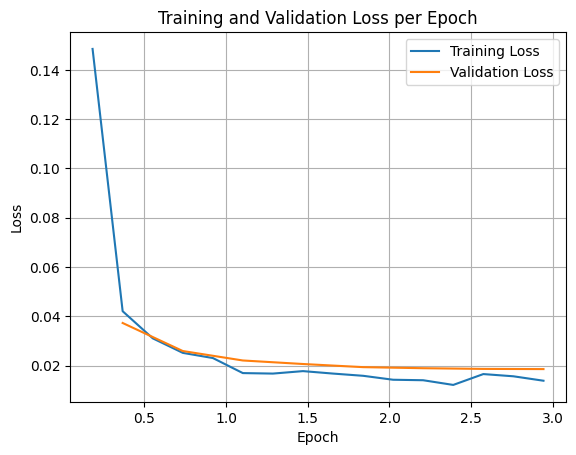

In [ ]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Test the fine-tuned model

Let's compare your fine-tuned model performance against the base model! Test a few inputs by updating `user_prompt`.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel

output_dir ="/content/mobile-actions-functiongemma"

# Create Transformers inference pipeline
gemma_model = "google/functiongemma-270m-it"
trained_model = AutoModelForCausalLM.from_pretrained(
    gemma_model,
    device_map="auto")

trained_model = PeftModel.from_pretrained(trained_model, output_dir)
trained_model = trained_model.merge_and_unload()
trained_model.eval()

tokenizer = AutoTokenizer.from_pretrained(output_dir)
pipe = pipeline("text-generation", model=trained_model, tokenizer=tokenizer)
pipe_base = pipeline("text-generation", model=gemma_model, device_map="auto")

# Test a prompt
user_prompt = "Schedule a \"team meeting\" tomorrow at 4pm."  #@param {type:"string"}
messages = [
    {"role": "developer", "content": "Current date and time given in YYYY-MM-DDTHH:MM:SS format: 2024-11-15T05:59:00. You are a model that can do function calling with the following functions"},
    {"role": "user", "content": user_prompt}
]

# Reuse the tools from the sample
tools = json.loads(dataset[0]['text'])['tools']

prompt = tokenizer.apply_chat_template(
    messages,
    tools=tools,
    tokenize=False,
    add_generation_prompt=True)

print(f"\n\033[1mPrompt:\033[0m {prompt}")
output = pipe(prompt, max_new_tokens=max_token_count)
output_base = pipe_base(prompt, max_new_tokens=max_token_count)
model_output = output[0]['generated_text'][len(prompt):].strip()
model_output_base = output_base[0]['generated_text'][len(prompt):].strip()

print(f"\n\033[1mFine-tuned model output:\033[0m {model_output}")

print(f"\n\033[1mBase model output:\033[0m       {model_output_base}")

Device set to use cuda:0
Device set to use cuda:0



Prompt: <bos><start_of_turn>developer
Current date and time given in YYYY-MM-DDTHH:MM:SS format: 2024-11-15T05:59:00. You are a model that can do function calling with the following functions<start_function_declaration>declaration:show_map{description:<escape>Shows a location on the map.<escape>,parameters:{properties:{query:{description:<escape>The location to search for. May be the name of a place, a business, or an address.<escape>,type:<escape>STRING<escape>}},required:[<escape>query<escape>],type:<escape>OBJECT<escape>}}<end_function_declaration><start_function_declaration>declaration:create_calendar_event{description:<escape>Creates a new calendar event.<escape>,parameters:{properties:{datetime:{description:<escape>The date and time of the event in the format YYYY-MM-DDTHH:MM:SS.<escape>,type:<escape>STRING<escape>},title:{description:<escape>The title of the event.<escape>,type:<escape>STRING<escape>}},required:[<escape>title<escape>,<escape>datetime<escape>],type:<escape>OBJEC

### Evaluate the fine-tuned model

Evaluating a fine-tuned model is essential to ensure that the process actually improved the model's performance without introducing new issues.

In [ ]:
#@title Helper functions for evaluation

import pandas as pd

def extract_function_call(model_output):
    """
    Parses a string containing specific function call markers and returns
    a list of function call objects. Here is an example of the obejct:

    ```
    <start_function_call>call:open_map{query:<escape>San Francisco<escape>}<end_function_call>
    ```

    Args:
        model_output (str): The model output string.

    Returns:
        list: A list of dictionaries representing the function calls.
    """
    results = []

    # Pattern to extract the full content of a single function call
    # Flags: DOTALL allows matching across newlines if necessary
    call_pattern = r"<start_function_call>(.*?)<end_function_call>"
    raw_calls = re.findall(call_pattern, model_output, re.DOTALL)

    for raw_call in raw_calls:
        # Check if the content starts with 'call:'
        if not raw_call.strip().startswith("call:"):
            continue

        # Extract function name
        # Expected format: call:func_name{...}
        try:
            # Split only on the first brace to separate name and args
            pre_brace, args_segment = raw_call.split("{", 1)

            function_name = pre_brace.replace("call:", "").strip()

            # Remove the trailing closing brace '}'
            args_content = args_segment.strip()
            if args_content.endswith("}"):
                args_content = args_content[:-1]

            arguments = {}

            # Pattern to extract arguments
            # Looks for: key:<escape>value<escape>
            # The key pattern [^:,]* ensures we don't accidentally eat previous commas
            arg_pattern = r"(?P<key>[^:,]*?):<escape>(?P<value>.*?)<escape>"

            arg_matches = re.finditer(arg_pattern, args_content, re.DOTALL)

            for match in arg_matches:
                key = match.group("key").strip()
                value = match.group("value")
                arguments[key] = value

            results.append({
                "function": {
                    "name": function_name,
                    "arguments": arguments
                }
            })

        except ValueError:
            # Handles cases where syntax might be malformed (e.g., missing '{')
            continue

    return results

def extract_text(model_output):
    """
    Extracts text content and removing the <end_of_turn> marker.

    Args:
        model_output (str): The model output string.

    Returns:
        str: The cleaned text.
    """
    if not model_output or model_output.startswith("<start_function_call>"):
        return None
    return model_output.replace("<end_of_turn>", "").strip()

from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset

def get_eval_logs(dataset, pipe):
  batch_size = 1
  logs = []
  # Select a random sample from the test dataset
  for i, output in enumerate(pipe(KeyDataset(dataset, "prompt"), batch_size=batch_size)):
    orig_data = dataset[i]['text']
    messages = json.loads(orig_data)['messages']
    user_message = messages[1]
    assistant_first_message = messages[2]
    input_prompt = dataset[i]['prompt']
    # Generate the output
    model_output_only = output[0]['generated_text'][len(input_prompt):].strip()

    logs.append(
        {
            # The original user prompt/query.
            "user": user_message['content'],

            # List of ground truth function call objects.
            "target_fc": assistant_first_message.get('tool_calls', []),

            # Ground truth text response.
            "target_text": assistant_first_message.get('content'),

            # List of model-generated function call objects.
            "output_fc": extract_function_call(model_output_only),

            # Model-generated text response.
            "output_text": extract_text(model_output_only),
        }
    )

    if (i + 1) % batch_size == 0:
      print(f"Eval process: {(i + 1) * 100.0 / len(dataset):.2f}%")
  return logs

def get_scored_data_frame(dataset, pipe):
  logs = get_eval_logs(dataset, pipe)
  logs_df = pd.DataFrame.from_records(logs)

  scored = pd.DataFrame()
  scored['user'] = logs_df['user']
  scored['target_names'] = logs_df['target_fc'].apply(lambda x: [fc['function']['name'] for fc in x])
  scored['output_names'] = logs_df['output_fc'].apply(lambda x: [fc['function']['name'] for fc in x])
  scored["target_arguments"] = logs_df['target_fc'].apply(lambda x: [dict(sorted(fc['function']['arguments'].items())) for fc in x])
  scored["output_arguments"] = logs_df['output_fc'].apply(lambda x: [dict(sorted(fc['function']['arguments'].items())) for fc in x])
  scored['target_text'] = logs_df['target_text']
  scored['output_text'] = logs_df['output_text']
  scored["correct_names"] = scored["target_names"] == scored["output_names"]
  scored["correct_arguments"] = scored["target_arguments"] == scored["output_arguments"]
  scored["correct"] = scored["correct_names"] & scored["correct_arguments"]

  return scored

def review(scored):
  scored["incorrect_names"] = scored["target_names"] != scored["output_names"]
  scored["incorrect_arguments"] = scored["target_arguments"] != scored["output_arguments"]
  scored["incorrect"] = scored["incorrect_names"] | scored["incorrect_arguments"]

  for index, row in scored[scored["incorrect"]].iterrows():
    print(f"\033[1mSample #{index} prompt  \033[0m: {row["user"]}")
    print(f"\033[1mSample #{index} expected\033[0m: {row["target_names"]}, {row["target_arguments"]}")
    print(f"\033[1mSample #{index} actual  \033[0m: {row["output_names"]}, {row["output_arguments"]}")
    print("---------------")


In [ ]:
import re
from random import randint

#@title Evaluate the base model

base_scored = get_scored_data_frame(
    eval_dataset,
    pipeline("text-generation", model=gemma_model, device_map="auto", temperature = 0.001),
)

base_scored

Device set to use cuda:0


Eval process: 0.10%
Eval process: 0.21%
Eval process: 0.31%
Eval process: 0.42%
Eval process: 0.52%
Eval process: 0.62%
Eval process: 0.73%
Eval process: 0.83%
Eval process: 0.94%
Eval process: 1.04%
Eval process: 1.14%
Eval process: 1.25%
Eval process: 1.35%
Eval process: 1.46%
Eval process: 1.56%
Eval process: 1.66%
Eval process: 1.77%
Eval process: 1.87%
Eval process: 1.98%
Eval process: 2.08%
Eval process: 2.19%
Eval process: 2.29%
Eval process: 2.39%
Eval process: 2.50%
Eval process: 2.60%
Eval process: 2.71%
Eval process: 2.81%
Eval process: 2.91%
Eval process: 3.02%
Eval process: 3.12%
Eval process: 3.23%
Eval process: 3.33%
Eval process: 3.43%
Eval process: 3.54%
Eval process: 3.64%
Eval process: 3.75%
Eval process: 3.85%
Eval process: 3.95%
Eval process: 4.06%
Eval process: 4.16%
Eval process: 4.27%
Eval process: 4.37%
Eval process: 4.47%
Eval process: 4.58%
Eval process: 4.68%
Eval process: 4.79%
Eval process: 4.89%
Eval process: 4.99%
Eval process: 5.10%
Eval process: 5.20%


,user,target_names,output_names,target_arguments,output_arguments,target_text,output_text,correct_names,correct_arguments,correct
0,Can you show me the location of the Reyes Adob...,[show_map],[show_map],[{'query': 'Reyes Adobe Historical Site'}],[{'query': 'Reyes Adobe Historical Site'}],None,None,True,True,True
1,Can you show me the location of the nearest Ma...,[show_map],[show_map],[{'query': 'nearest Maison du Monde store in B...,[{'query': 'Maison du Monde store in Bordeaux'}],None,None,True,False,False
2,Save a new contact for Riya Sharma with the ph...,"[create_contact, create_calendar_event]","[create_contact, turn_off_flashlight, turn_on_...","[{'email': 'riya.sharma@techcorp.in', 'first_n...","[{'email': 'riya.sharma@techcorp.in', 'first_n...",None,None,False,False,False
3,"Set a calendar event titled ""Call with Investo...",[create_calendar_event],[create_calendar_event],"[{'datetime': '2025-11-28T14:00:00', 'title': ...","[{'datetime': '2025-11-28T4:00:00', 'title': '...",None,None,True,False,False
4,Please show me the location of the Apex Logist...,"[show_map, create_calendar_event]","[show_map, turn_on_flashlight, create_calendar...",[{'query': 'Apex Logistics Warehouse at 789 In...,[{'query': 'Apex Logistics Warehouse Mancheste...,None,None,False,False,False
...,...,...,...,...,...,...,...,...,...,...
956,I need to save a new contact named Kenji Tanak...,[create_contact],[create_contact],"[{'email': 'kenji.tanaka@examplecorp.jp', 'fir...","[{'email': 'kenji.tanaka@examplecorp.jp', 'fir...",None,None,True,True,True
957,Can you please turn on my flashlight? I droppe...,[turn_on_flashlight],[turn_on_flashlight],[{}],[{}],None,None,True,True,True
958,I need to add a new contact. The name is Sofia...,[create_contact],[create_contact],"[{'first_name': 'Sofia', 'last_name': 'Petrova...","[{'first_name': 'Sofia', 'last_name': 'Petrova...",None,None,True,True,True
959,I need to turn on the flashlight on my phone r...,[turn_on_flashlight],[turn_on_flashlight],[{}],[{}],None,None,True,True,True


In [ ]:
#@title Evaluate the fine-tuned model

trained_scored = get_scored_data_frame(
    eval_dataset,
    pipeline("text-generation", model=trained_model, tokenizer=tokenizer, temperature = 0.001)
)

trained_scored

Device set to use cuda:0


Eval process: 0.10%
Eval process: 0.21%
Eval process: 0.31%
Eval process: 0.42%
Eval process: 0.52%
Eval process: 0.62%
Eval process: 0.73%
Eval process: 0.83%
Eval process: 0.94%
Eval process: 1.04%
Eval process: 1.14%
Eval process: 1.25%
Eval process: 1.35%
Eval process: 1.46%
Eval process: 1.56%
Eval process: 1.66%
Eval process: 1.77%
Eval process: 1.87%
Eval process: 1.98%
Eval process: 2.08%
Eval process: 2.19%
Eval process: 2.29%
Eval process: 2.39%
Eval process: 2.50%
Eval process: 2.60%
Eval process: 2.71%
Eval process: 2.81%
Eval process: 2.91%
Eval process: 3.02%
Eval process: 3.12%
Eval process: 3.23%
Eval process: 3.33%
Eval process: 3.43%
Eval process: 3.54%
Eval process: 3.64%
Eval process: 3.75%
Eval process: 3.85%
Eval process: 3.95%
Eval process: 4.06%
Eval process: 4.16%
Eval process: 4.27%
Eval process: 4.37%
Eval process: 4.47%
Eval process: 4.58%
Eval process: 4.68%
Eval process: 4.79%
Eval process: 4.89%
Eval process: 4.99%
Eval process: 5.10%
Eval process: 5.20%


,user,target_names,output_names,target_arguments,output_arguments,target_text,output_text,correct_names,correct_arguments,correct
0,Can you show me the location of the Reyes Adob...,[show_map],[show_map],[{'query': 'Reyes Adobe Historical Site'}],[{'query': 'Reyes Adobe Historical Site'}],None,None,True,True,True
1,Can you show me the location of the nearest Ma...,[show_map],[],[{'query': 'nearest Maison du Monde store in B...,[],None,None,False,False,False
2,Save a new contact for Riya Sharma with the ph...,"[create_contact, create_calendar_event]","[create_contact, create_calendar_event]","[{'email': 'riya.sharma@techcorp.in', 'first_n...","[{'email': 'riya.sharma@techcorp.in', 'first_n...",None,None,True,True,True
3,"Set a calendar event titled ""Call with Investo...",[create_calendar_event],[create_calendar_event],"[{'datetime': '2025-11-28T14:00:00', 'title': ...","[{'datetime': '2025-11-28T14:00:00', 'title': ...",None,None,True,True,True
4,Please show me the location of the Apex Logist...,"[show_map, create_calendar_event]",[],[{'query': 'Apex Logistics Warehouse at 789 In...,[],None,None,False,False,False
...,...,...,...,...,...,...,...,...,...,...
956,I need to save a new contact named Kenji Tanak...,[create_contact],[create_contact],"[{'email': 'kenji.tanaka@examplecorp.jp', 'fir...","[{'email': 'kenji.tanaka@examplecorp.jp', 'fir...",None,None,True,True,True
957,Can you please turn on my flashlight? I droppe...,[turn_on_flashlight],[turn_on_flashlight],[{}],[{}],None,None,True,True,True
958,I need to add a new contact. The name is Sofia...,[create_contact],[create_contact],"[{'first_name': 'Sofia', 'last_name': 'Petrova...","[{'first_name': 'Sofia', 'last_name': 'Petrova...",None,None,True,True,True
959,I need to turn on the flashlight on my phone r...,[turn_on_flashlight],[turn_on_flashlight],[{}],[{}],None,None,True,True,True


In [ ]:
#@title Compare the score of the base and fine-tuned models

# Optional: save the score in json file
trained_scored.to_json('scored_df_20251215_trained.json')
base_scored.to_json('scored_df_20251215_base.json')

print(f"\033[1mBase model score\033[0m       : {base_scored["correct"].mean()}")
print(f"\033[1mFine-tuned model score\033[0m : {trained_scored["correct"].mean()}")

Base model score       : 0.6024973985431842
Fine-tuned model score : 0.7804370447450573


## Review what is not matching

The score will tell how much eval data got exactly correct function calls. It gives the lower bound of correctness. Some output might not match the eval date but still acceptable. For example, the `show_map` function call below:

* show_map:{'query': 'Maison Marulaz, Besançon, France'}
* show_map:{'query': 'Maison Marulaz in Besançon, France'}

Let's take a look at the eval date without exact match. Many of them could also be acceptable.

In [ ]:
review(trained_scored)

Sample #1 prompt  : Can you show me the location of the nearest Maison du Monde store in Bordeaux on a map?
Sample #1 expected: ['show_map'], [{'query': 'nearest Maison du Monde store in Bordeaux'}]
Sample #1 actual  : [], []
---------------
Sample #4 prompt  : Please show me the location of the Apex Logistics Warehouse at 789 Industrial Drive, Manchester, UK, and also schedule a calendar event called 'Warehouse Inspection' for April 15th, 2025, at 9 AM.
Sample #4 expected: ['show_map', 'create_calendar_event'], [{'query': 'Apex Logistics Warehouse at 789 Industrial Drive, Manchester, UK'}, {'datetime': '2025-04-15T09:00:00', 'title': 'Warehouse Inspection'}]
Sample #4 actual  : [], []
---------------
Sample #6 prompt  : Please show me the Pasadena Community Garden on the map and also schedule a calendar event called "Volunteer Shift" for next Saturday at 9:30 AM.
Sample #6 expected: ['show_map', 'create_calendar_event'], [{'query': 'Pasadena Community Garden'}, {'datetime': '2024-12-0

Does the model call the function you'd expect?

If you're not getting the results you want, you can try [using different hyperparameters](#scrollTo=-BJFoOdL0y8w) to train the model, or updating your training dataset to contain more representative examples.

Once you're happy with the results, you can save your model to Hugging Face Hub.

## Save your model and upload to Hugging Face Hub
**You now have a customized FunctionGemma 270M model trained with LoRA! 🎉**

Upload it to a repository on Hugging Face Hub so you easily share your model or access it later.

In [ ]:
from huggingface_hub import ModelCard, ModelCardData, whoami

output_dir = "/content/mobile-actions-functiongemma"
gemma_model = "google/functiongemma-270m-it"
trained_model = AutoModelForCausalLM.from_pretrained(
    gemma_model,
    device_map="auto")

trained_model = PeftModel.from_pretrained(trained_model, output_dir)
trained_model = trained_model.merge_and_unload()
trained_model.eval()

tokenizer = AutoTokenizer.from_pretrained(output_dir)

#@markdown Name your model
model_name = "lora-mobile-actions"    #@param {type:"string"}

username = whoami()['name']
hf_repo_id = f"{username}/functiongemma-270m-it-{model_name}"

repo_url = trained_model.push_to_hub(hf_repo_id, create_repo=True, commit_message="Upload model")
tokenizer.push_to_hub(hf_repo_id)

card_content = f"""
---
base_model: {gemma_model}
tags:
- function-calling
- mobile-actions
- gemma
- PEFT
- LoRA
---
A LoRA fine-tuned model based on `{gemma_model}`."""
card = ModelCard(card_content)

card.push_to_hub(hf_repo_id)

print(f"Uploaded to {repo_url}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to https://huggingface.co/pmarruda/functiongemma-270m-it-lora-mobile-actions/commit/bde14938163a9df183cd639ef96160975646ac08


## Conversion to .litertlm for on-device deployment

The first step is to install the necessary libraries using the `pip` package installer.

In [ ]:
!pip uninstall -y tensorflow
!pip install ai-edge-torch-nightly --force-reinstall
!pip install ai-edge-litert-nightly

### Build the .litertlm from the fine-tuned model

After running the script below, you can find the converted model in located in `/content/litertlm/mobile-actions_q8_ekv1024.litertlm` in the colab environment. Copy it to a persistent storage like Google Drive.

Since we fine-tuned with LoRA we now need to:
1. Load original model
2. Add the trained LoRA adapters on top
3. Merge them
4. Save the merged model to /content/merged_model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

checkpoint_dir = "/content/mobile-actions-functiongemma"

gemma_model = "google/functiongemma-270m-it"
trained_model = AutoModelForCausalLM.from_pretrained(
    gemma_model,
    device_map="auto")

trained_model = PeftModel.from_pretrained(trained_model, checkpoint_dir)
trained_model = trained_model.merge_and_unload()
trained_model.eval()

trained_model.save_pretrained("/content/merged_model")
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)

In [ ]:
import os
from ai_edge_torch.generative.examples.gemma3 import gemma3
from ai_edge_torch.generative.utilities import converter
from ai_edge_torch.generative.utilities.export_config import ExportConfig
from ai_edge_torch.generative.layers import kv_cache


# Metadata for FunctionGemma
llm_metadata = r"""start_token: {
    token_ids: {
        ids: [ 2 ]
    }
}
stop_tokens: {
    token_str: "<end_of_turn>"
}
stop_tokens: {
    token_str: "<start_function_response>"
}
llm_model_type: {
    function_gemma: {}
}
"""


litertlm_output_dir = '/content/litertlm'
os.makedirs(litertlm_output_dir, exist_ok=True)

# Create the LLM metadata file
metadata_path = os.path.join(litertlm_output_dir, 'base_llm_metadata.textproto')
with open(metadata_path, 'w') as f:
  f.write(llm_metadata)

# Import the weights from the merged model and build the PyTorch model
pytorch_model = gemma3.build_model_270m("/content/merged_model")

# Setup the export configurations and parameters for text generation models.
export_config = ExportConfig()
export_config.kvcache_layout = kv_cache.KV_LAYOUT_TRANSPOSED
export_config.mask_as_input = True


# Convert to LiteRT-LM Format
converter.convert_to_litert(
    pytorch_model,
    output_path=litertlm_output_dir,
    output_name_prefix="mobile-actions",
    prefill_seq_len=256,
    kv_cache_max_len=1024,
    quantize="dynamic_int8",
    export_config=export_config,
    tokenizer_model_path=os.path.join(checkpoint_dir, 'tokenizer.model'),
    base_llm_metadata_path=metadata_path,
    output_format="litertlm",
)


### Save the `.litertlm` on Google Drive

To deploy the converted model on [Google AI Edge Gallery](https://play.google.com/store/apps/details?id=com.google.ai.edge.gallery), we can first store the model on Google Drive. On the Gallery app, import the model from Google Drive later.

In [ ]:
#@title Mounting Google Drive on the colab environment

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#@title Save the `.litertlm` on Google Drive

!mkdir -p /content/drive/MyDrive/mobile-actions/
!cp /content/litertlm/mobile-actions_q8_ekv1024.litertlm /content/drive/MyDrive/mobile-actions/

## Summary and next steps

Congratulations! You have completed the first part of [Fine-tune FunctionGemma 270M for Mobile Actions](https://ai.google.dev/gemma/docs/mobile-actions) - and you did it for free with the help of LoRA! :)

You have successfully finetuned the FunctionGemma 270M with the Mobile Actions dataset and converted it to `.litertlm` format.